# Análise de perfis residenciais alemães (OPSD)

Análise comparativa de 3 perfis residenciais reais do **Open Power System Data (OPSD)**,
região de Konstanz, Alemanha, com estimativa de SOH de bateria via MLBatLife.

Os perfis são referidos neste trabalho como:
- **Residencial Alemão A** ↔ DE_KN_residential3 (consumo padrão)
- **Residencial Alemão B** ↔ DE_KN_residential4 (bomba de calor + VE)
- **Residencial Alemão C** ↔ DE_KN_residential6 (perfil alternativo)

**Fonte:** Open Power System Data. 2020. *Data Package Household Data*. Version 2020-04-15.
https://data.open-power-system-data.org/household_data/2020-04-15/
Licença: CC-BY 4.0.

## Etapas
1. Carregamento dos dados OPSD (colunas selecionadas).
2. Exploração: intervalos de datas, dados faltantes.
3. Conversão para formato MLBatLife (`Time`, `Power` em Watts).
4. Visualização dos perfis de potência residual.
5. Estimativa de SOH com modelo Random Forest pré-treinado.
6. Comparação das curvas de SOH entre os 3 perfis.
7. Classificação SOH e estimativa de EOL.
8. Estatísticas resumidas.

In [ ]:
# ── setup ───────────────────────────────────────────────────────────
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

BASE_DIR = (
    Path(__file__).resolve().parent.parent.parent
    if "__file__" in dir()
    else Path.cwd().resolve().parent.parent
)
MLBAT_DIR = (BASE_DIR / "code" / "MLBatLife").resolve()
OPSD_CSV  = BASE_DIR / "code" / "data" / "opsd" / "household_data_1min_singleindex.csv"
OUT_DIR   = BASE_DIR / "code" / "data" /  "pic"
OUT_DIR.mkdir(parents=True, exist_ok=True)

import sys
if str(MLBAT_DIR) not in sys.path:
    sys.path.insert(0, str(MLBAT_DIR))

import MLBatLife_Pred as blp

plt.rcParams.update({"figure.dpi": 120})

# Perfis residenciais OPSD com geração PV (Konstanz, Alemanha)
# Mapeamento fonte → alias adotado neste trabalho:
#   DE_KN_residential3 → Residencial Alemão A (consumo padrão)
#   DE_KN_residential4 → Residencial Alemão B (bomba de calor + veículo elétrico)
#   DE_KN_residential6 → Residencial Alemão C (perfil alternativo)
HOUSEHOLDS = {
    "residential3": {"alias": "Residencial Alemão A", "carga": "consumo padrão"},
    "residential4": {"alias": "Residencial Alemão B", "carga": "bomba de calor + veículo elétrico"},
    "residential6": {"alias": "Residencial Alemão C", "carga": "perfil alternativo"},
}

# Parâmetros MLBatLife
STRATEGY = 0   # 0: Greedy
QNOM     = 5   # kWh (capacidade nominal da bateria)

# Limiares de classificação SOH
SOH_SAUDAVEL = 0.90   # SOH ≥ 0.90 → Saudável
SOH_ATENCAO  = 0.80   # 0.80 ≤ SOH < 0.90 → Atenção
# SOH < 0.80 → Fim de vida (EOL)

# Dias iniciais excluídos da regressão (break-in)
BREAK_IN = 30

In [19]:
# 1) Carregar apenas colunas necessárias (7 de 71) para reduzir uso de memória
cols = ["utc_timestamp"]
for hh in HOUSEHOLDS:
    cols.append(f"DE_KN_{hh}_grid_import")
    cols.append(f"DE_KN_{hh}_grid_export")

print(f"Carregando {OPSD_CSV.name} ({len(cols)} colunas)...")
df_opsd = pd.read_csv(OPSD_CSV, usecols=cols, parse_dates=["utc_timestamp"])
print(f"Linhas: {len(df_opsd):,}")
print(f"Período: {df_opsd['utc_timestamp'].min()} → {df_opsd['utc_timestamp'].max()}")
df_opsd.head()

Carregando household_data_1min_singleindex.csv (7 colunas)...
Linhas: 2,307,133
Período: 2014-12-11 17:59:00+00:00 → 2019-05-01 22:11:00+00:00


,utc_timestamp,DE_KN_residential3_grid_export,DE_KN_residential3_grid_import,DE_KN_residential4_grid_export,DE_KN_residential4_grid_import,DE_KN_residential6_grid_export,DE_KN_residential6_grid_import
0,2014-12-11 17:59:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-12-11 18:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-12-11 18:01:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN
3,2014-12-11 18:02:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-12-11 18:03:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
# 2) Disponibilidade de dados por perfil
print("=== Disponibilidade de dados por perfil ===\n")
for hh, hh_info in HOUSEHOLDS.items():
    col_imp = f"DE_KN_{hh}_grid_import"
    col_exp = f"DE_KN_{hh}_grid_export"
    mask = df_opsd[col_imp].notna() & df_opsd[col_exp].notna()
    sub = df_opsd.loc[mask]
    first = sub["utc_timestamp"].min()
    last  = sub["utc_timestamp"].max()
    n_days = (last - first).days
    pct_nan_imp = df_opsd[col_imp].isna().mean() * 100
    pct_nan_exp = df_opsd[col_exp].isna().mean() * 100
    print(f"{hh_info['alias']}  (fonte: DE_KN_{hh}):")
    print(f"  Período com dados: {first.date()} → {last.date()}  ({n_days} dias)")
    print(f"  NaN grid_import: {pct_nan_imp:.1f}%  |  NaN grid_export: {pct_nan_exp:.1f}%")
    print()

=== Disponibilidade de dados por perfil ===

Residencial Alemão A  (fonte: DE_KN_residential3):
  Período com dados: 2016-02-28 → 2017-07-08  (495 dias)
  NaN grid_import: 69.0%  |  NaN grid_export: 41.3%

Residencial Alemão B  (fonte: DE_KN_residential4):
  Período com dados: 2015-10-10 → 2018-02-04  (848 dias)
  NaN grid_import: 47.1%  |  NaN grid_export: 47.1%

Residencial Alemão C  (fonte: DE_KN_residential6):
  Período com dados: 2016-05-13 → 2018-04-08  (695 dias)
  NaN grid_import: 44.0%  |  NaN grid_export: 56.6%



In [21]:
# 3) Função de conversão OPSD → MLBatLife
def opsd_to_mlbatlife(df, household_id):
    """Converte dados OPSD para formato MLBatLife (Time, Power).

    Os dados OPSD são energia ACUMULADA (kWh).
    1. Calcula-se o delta entre minutos consecutivos (kWh/min).
    2. Converte-se para potência: P(W) = ΔE(kWh) × 60 000
    3. Potência residual: P = (Δimport − Δexport) × 60 000
    """
    prefix  = f"DE_KN_{household_id}_"
    col_imp = prefix + "grid_import"
    col_exp = prefix + "grid_export"

    sub = df[["utc_timestamp", col_imp, col_exp]].copy()

    # Manter apenas linhas com dados válidos em ambas as colunas
    mask = sub[col_imp].notna() & sub[col_exp].notna()
    sub = sub.loc[mask].copy()

    # Delta (energia por intervalo de 1 min, kWh)
    sub["d_import"] = sub[col_imp].diff()
    sub["d_export"] = sub[col_exp].diff()

    # Remover primeira linha (NaN do diff) e eventuais deltas negativos
    sub = sub.iloc[1:].copy()
    sub.loc[sub["d_import"] < 0, "d_import"] = 0.0
    sub.loc[sub["d_export"] < 0, "d_export"] = 0.0

    # Primeira meia-noite completa
    first_midnight = sub["utc_timestamp"].dt.normalize().iloc[0]
    if sub["utc_timestamp"].iloc[0] != first_midnight:
        first_midnight += pd.Timedelta(days=1)

    sub = sub.loc[sub["utc_timestamp"] >= first_midnight].copy()

    # Truncar em dias completos (1440 min/dia)
    n_days = len(sub) // 1440
    sub = sub.iloc[:n_days * 1440].copy()

    # Potência residual (W) = (delta_import - delta_export) × 60 000
    power = (sub["d_import"].values - sub["d_export"].values) * 60_000

    result = pd.DataFrame({
        "Time":  np.arange(len(power), dtype=float),
        "Power": power,
    })

    info = {
        "household": household_id,
        "start":     first_midnight,
        "n_days":    n_days,
        "n_minutes": len(result),
    }
    return result, info

print("Função opsd_to_mlbatlife corrigida (dados cumulativos → delta → W).")

Função opsd_to_mlbatlife corrigida (dados cumulativos → delta → W).


In [22]:
# 4) Converter e salvar cada perfil como CSV compatível com MLBatLife
profiles = {}
for hh in HOUSEHOLDS:
    df_mlb, info = opsd_to_mlbatlife(df_opsd, hh)
    out_path = BASE_DIR / "code" / "data" / "opsd" / f"profile_{hh}.csv"
    df_mlb.to_csv(out_path, index=False)
    profiles[hh] = {"df": df_mlb, "info": info, "path": out_path}
    print(f"{HOUSEHOLDS[hh]['alias']}: {info['n_days']} dias  |  início {info['start'].date()}  |  → {out_path.name}")

Residencial Alemão A: 495 dias  |  início 2016-02-29  |  → profile_residential3.csv
Residencial Alemão B: 847 dias  |  início 2015-10-11  |  → profile_residential4.csv
Residencial Alemão C: 694 dias  |  início 2016-05-14  |  → profile_residential6.csv


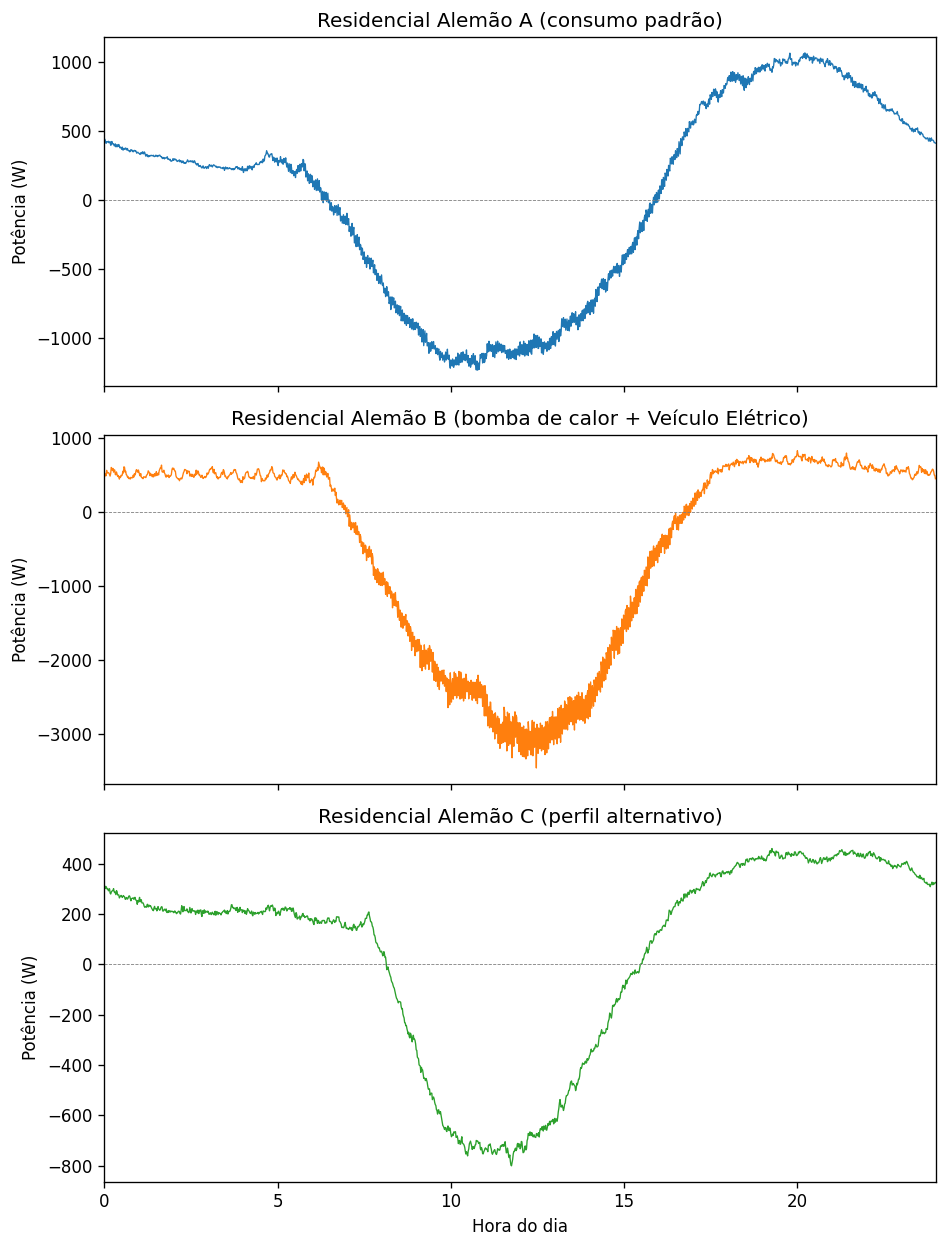

In [23]:
# 5) Perfil médio diário de potência residual
fig, axes = plt.subplots(len(HOUSEHOLDS), 1, figsize=(8, 3.5 * len(HOUSEHOLDS)), sharex=True)
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
hours = np.arange(1440) / 60.0  # eixo em horas (0–24)

for ax, (hh, pdata), color in zip(axes, profiles.items(), colors):
    power = pdata["df"]["Power"].values
    n_full = (len(power) // 1440) * 1440
    daily_matrix = power[:n_full].reshape(-1, 1440)
    avg_day = daily_matrix.mean(axis=0)
    ax.plot(hours, avg_day, color=color, linewidth=0.8)
    ax.set_ylabel("Potência (W)")
    ax.set_title(f"{HOUSEHOLDS[hh]['alias']} ({HOUSEHOLDS[hh]['carga']})")
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")

axes[-1].set_xlabel("Hora do dia")
axes[-1].set_xlim(0, 24)
plt.tight_layout()
plt.savefig(OUT_DIR / "opsd_profiles_avg_day.png", dpi=300)
plt.show()

In [24]:
# 6) Estimativa de SOH para cada perfil
os.chdir(MLBAT_DIR)

soh_results = {}
for hh, pdata in profiles.items():
    df_mlb   = pdata["df"]
    m_time   = df_mlb["Time"].values
    inp_prof = df_mlb["Power"].values

    features, day = blp.extract_features(m_time, inp_prof)
    soh_hat       = blp.estimate_soh(features, day, STRATEGY, QNOM)

    soh_results[hh] = {"day": day, "soh": soh_hat, "features": features}
    print(f"{HOUSEHOLDS[hh]['alias']}: {len(day)} dias  |  SOH final = {soh_hat[-1]:.4f}")

Residencial Alemão A: 495 dias  |  SOH final = 0.9279
Residencial Alemão B: 847 dias  |  SOH final = 0.8956
Residencial Alemão C: 694 dias  |  SOH final = 0.9216


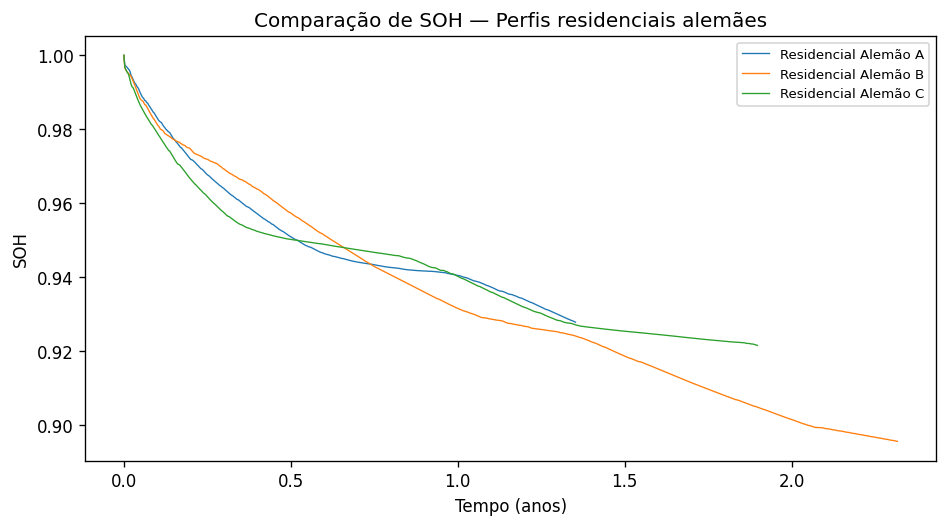

In [25]:
# 7) Comparação das curvas de SOH
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for (hh, res), color in zip(soh_results.items(), colors):
    years = res["day"] / 365.25
    ax.plot(years, res["soh"], color=color, linewidth=0.8, label=HOUSEHOLDS[hh]["alias"])

ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.set_xlabel("Tempo (anos)")
ax.set_ylabel("SOH")
ax.set_title("Comparação de SOH — Perfis residenciais alemães")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / "opsd_soh_comparison.png", dpi=300)
plt.show()

In [26]:
# 8) Estatísticas resumidas com classificação e EOL

# Salvar SOH diário para cada perfil
for hh, res in soh_results.items():
    soh_daily = pd.DataFrame({"Dia": res["day"], "SOH_est": res["soh"]})
    soh_daily.to_csv(OUT_DIR / f"opsd_{hh}_soh_daily.csv", index=False)

rows = []
for hh, res in soh_results.items():
    soh = res["soh"]
    day = res["day"]
    soh_final = float(soh[-1])

    # SOH no dia 365 (1 ano), se disponível
    mask_1y = day <= 365
    soh_1ano = float(soh[mask_1y][-1]) if mask_1y.any() else None

    # Classificação final
    if soh_final >= SOH_SAUDAVEL:
        classif = "Saudável"
    elif soh_final >= SOH_ATENCAO:
        classif = "Atenção"
    else:
        classif = "Fim de vida"

    # EOL estimado — slope da regressão (curva completa s/ break-in),
    # projetado a partir do último SOH observado
    eol_reached = soh < SOH_ATENCAO
    if eol_reached.any():
        eol_day = float(day[eol_reached][0])
    else:
        mask = day >= BREAK_IN
        slope, _intercept = np.polyfit(day[mask], soh[mask], 1)
        if slope < 0:
            eol_day = day[-1] + (SOH_ATENCAO - soh[-1]) / slope
        else:
            eol_day = None

    eol_anos = round(eol_day / 365.25, 1) if eol_day else "—"

    rows.append({
        "Perfil":          HOUSEHOLDS[hh]["alias"],
        "Dias":            len(day),
        "SOH@1ano":        round(soh_1ano, 4) if soh_1ano else "—",
        "SOH final":       round(soh_final, 4),
        "Classificação":   classif,
        "EOL est. (anos)": eol_anos,
    })

summary_opsd = pd.DataFrame(rows)
summary_opsd.to_csv(OUT_DIR / "opsd_soh_summary.csv", index=False)
summary_opsd

,Perfil,Dias,SOH@1ano,SOH final,Classificação,EOL est. (anos)
0,Residencial Alemão A,495,0.9405,0.9279,Saudável,4.9
1,Residencial Alemão B,847,0.9316,0.8956,Atenção,4.9
2,Residencial Alemão C,694,0.9403,0.9216,Saudável,6.3
